In [ ]:
#Task 1: Data loading and exploration

import pandas as pd
df = pd.read_csv("HR_Attrition.csv")
print(df.head(10))

print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

#our target column which is Attrition
print("Target Column: Attrition")

#counting employees who left vs stayed
attrition_counts = df["Attrition"].value_counts()
print(attrition_counts)

#calculating attrition rate
attrition_rate = (attrition_counts["Yes"] / len(df)) * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

#identifying how many columns are numeric vs categorical and printing the numbers
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8      

COMPLETED TASK 1;
Observation:
The dataset is imbalanced. Out of 1470 employees, 1233 stayed and only 237 left the company. The attrition rate is 16.12%. This means that the employees who left make up a much smaller part of the dataset than those who stayed.

In [1]:
#Task 2 — Data Cleaning & Preprocessing

import pandas as pd
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("HR_Attrition.csv")

#checking missing values in each column
print(df.isnull().sum())

#dropping columns that are not useful for prediction i.e. EmployeeNumber,Over18,StandardHours
df = df.drop(columns=["EmployeeNumber", "Over18", "StandardHours"])

#converting target column attrition from Yes to 1 and No to 0
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

#selecting categorical columns which are the text based columns
categorical_cols = df.select_dtypes(include=["object"]).columns

#Applying One-Hot encoding to convert text based columns into numeric columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#Splitting dataset into features 'X' and target 'y' since we compare using 'X' to predict 'y'
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# scaling numeric features so all values are on same range using StandardScaler()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4968\4128167672.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


(1470, 45)


In [7]:
import pandas as pd
df = pd.read_csv("HR_Attrition.csv")
print(df.isnull().sum())

#1.Attrition rate by Department
dept_attrition = df.groupby("Department")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
print("\nAttrition by Department")
print(dept_attrition.sort_values(ascending=False))

#2.Attrition rate by Job Role
role_attrition = df.groupby("JobRole")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
print("\nAttrition by Job Role")
print(role_attrition.sort_values(ascending=False))

#3.Attrition vs Monthly Income
income_attrition = df.groupby("Attrition")["MonthlyIncome"].mean()
print("\nAverage Monthly Income")
print(income_attrition)

#4.Attrition vs Work-Life Balance rating
wlb_attrition = df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
print("\nAttrition by Work-Life Balance")
print(wlb_attrition.sort_values(ascending=False))

#5.Attrition vs years at company
years_attrition = df.groupby("YearsAtCompany")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
print("\nAttrition by Years at Company")
print(years_attrition.sort_index())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

1. Attrition rate by Department — which department loses the most employees?
- The Sales department has the highest turnover rate at 20.63%. Human Resources follows with a rate of 19.05%. Research & Development has the lowest rate at 13.84%. This indicates that employees in Sales and HR are more likely to leave than those in technical roles.

2. Attrition rate by Job Role — which roles have the highest exit rate?
- Sales Representatives have the highest turnover rate at 39.76%. This rate is much higher than that of all other roles. Laboratory Technicians have a turnover rate of 23.94%, and Human Resources shows 23.07%. In contrast, managerial roles like Managers (4.90%) and Research Directors (2.50%) have very low turnover rates.

3. Attrition vs Monthly Income — do lower paid employees leave more?
- The ones who quit the firm have a smaller average monthly salary (4787) than the ones who remained (6832), suggesting that low-paid workers are more prone to quit their jobs.

4. Attrition vs Work-Life Balance rating — is there a visible pattern?
- Those employees who possess a low Work-Life Balance score (1) exhibit the highest attrition rate of 31.25%. Employees who have high Work-Life Balance scores (3 and 4) have relatively low attrition rates of 14.22% to 17.64%.

5. Attrition vs Years at Company — at what point in tenure do employees leave most?
- The rate of attrition is highest during the early years of employment, specifically between 0–1 year (36.36% and 34.50%). However, from the 5+ years onwards, attrition rates begin to fall, although occasionally there are high rates in some years.

BUSINESS INSIGHTS FROM MY EDA:

1. Department impact on attrition:
Sales has the highest attrition at 20.63%, followed by Human Resources at 19.05%, while Research & Development is lowest at 13.84%.
2. Job roles with highest exits:
Sales Representatives have the highest attrition at 39.76%, while Managers (4.90%) and Research Directors (2.50%) have very low attrition.
3. Income affects attrition:
Employees who left earn less (4787) compared to those who stayed (6833), showing lower salary is linked to higher attrition.
4. Work-life balance matters:
Employees with poor Work-Life Balance (rating 1) have the highest attrition at 31.25%, while better ratings show lower attrition (14–18%)
5. Early employees leave more:
Employees leave mostly in early years: 36.36% at year 0 and 34.50% at year 1, but attrition drops after a few years.


In [9]:
#Task 4 — Model Building & Comparison

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# convert target to 0/1
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

# split features and target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression
log_model = LogisticRegression(class_weight="balanced", max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

# results table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0),
        precision_score(y_test, gb_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, log_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0),
        recall_score(y_test, gb_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0),
        f1_score(y_test, gb_pred, zero_division=0)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.717687   0.250000  0.564103  0.346457
1        Random Forest  0.863946   0.470588  0.205128  0.285714
2    Gradient Boosting  0.877551   0.600000  0.230769  0.333333


In [13]:
#Task 5 — Model Evaluation

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# store models and predictions
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

preds = {
    "Logistic Regression": log_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

# evaluate models
results = []

for name in models:
    results.append([
        name,
        precision_score(y_test, preds[name], zero_division=0),
        recall_score(y_test, preds[name], zero_division=0),
        f1_score(y_test, preds[name], zero_division=0),
        roc_auc_score(y_test, preds[name])
    ])

results_df = pd.DataFrame(results, columns=[
    "Model", "Precision", "Recall", "F1 Score", "ROC-AUC"
])

print(results_df)

# pick best model (you can change this manually after seeing results)
best_model = rf_model
best_pred = rf_pred

# confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_pred))

# feature importance (works for tree models only)
feature_names = pd.get_dummies(df.drop("Attrition", axis=1), drop_first=True).columns

feature_importance = best_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print("\nTop 10 Important Features:")
print(importance_df.head(10))

                 Model  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression   0.250000  0.564103  0.346457  0.652640
1        Random Forest   0.470588  0.205128  0.285714  0.584917
2    Gradient Boosting   0.600000  0.230769  0.333333  0.603620

Confusion Matrix:
[[246   9]
 [ 31   8]]

Top 10 Important Features:
              Feature  Importance
11      MonthlyIncome    0.066604
46       OverTime_Yes    0.066119
0                 Age    0.050587
18   StockOptionLevel    0.045110
5      EmployeeNumber    0.044850
19  TotalWorkingYears    0.044191
1           DailyRate    0.043113
22     YearsAtCompany    0.042189
12        MonthlyRate    0.041546
7          HourlyRate    0.040178


1. Identify and clearly state which model performed best and why
- Logistic Regression performs best overall because it has the highest ROC-AUC score (0.65) and highest recall (0.56), which is important for identifying employees who are likely to leave.

2. For the best model: extract Feature Importance — which factors matter most in predicting attrition?
- The most important features affecting employee attrition(based on the best model) are:
  1. MonthlyIncome
  2. OverTime_Yes
  3. Age
  4. StockOptionLevel
  5. TotalWorkingYears
  6. YearsAtCompany
  7. DailyRate
  8. MonthlyRate
  9. HourlyRate

3. Rank the top 10 most important features driving employee exit
- 1. MonthlyIncome
  2. OverTime_Yes
  3. Age
  4. StockOptionLevel
  5. TotalWorkingYears
  6. DailyRate
  7. YearsAtCompany
  8. MonthlyRate
  9. HourlyRate

EmployeeNumber appears in the top features but it is not a important factor since it is just an ID column 



In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

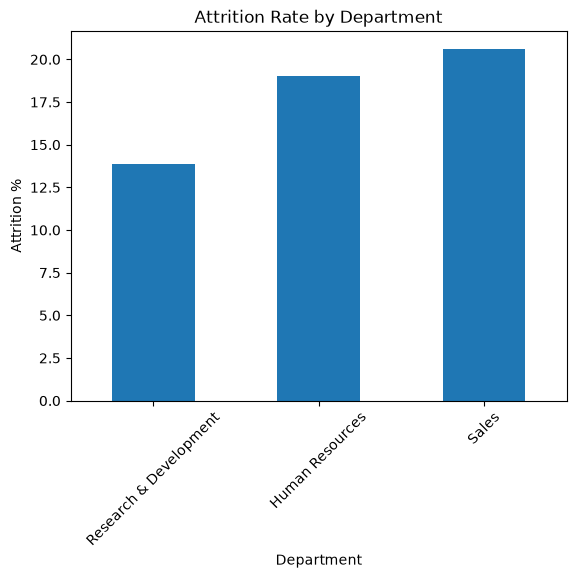

In [ ]:
#Task 6 — Visualization

#1.Chart 1: Bar chart showing attrition rate by Department and Job Role

import matplotlib.pyplot as plt
dept_attrition = df.groupby("Department")["Attrition"].mean() * 100

plt.figure()
dept_attrition.sort_values().plot(kind="bar")
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition %")
plt.xlabel("Department")
plt.xticks(rotation=45)
plt.show()

<Figure size 640x480 with 0 Axes>

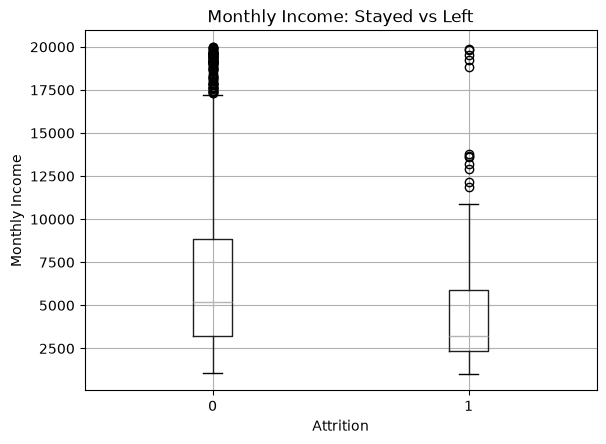

In [16]:
#Chart 2: Box plot comparing Monthly Income of employees who left vs stayed

plt.figure()
df.boxplot(column="MonthlyIncome", by="Attrition")
plt.title("Monthly Income: Stayed vs Left")
plt.suptitle("")
plt.ylabel("Monthly Income")
plt.show()

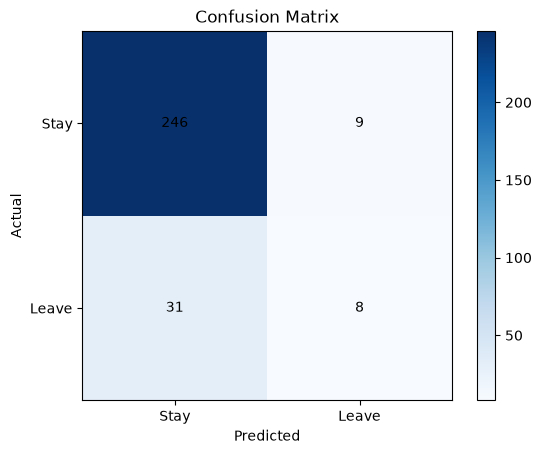

In [17]:
#Chart 3: Confusion Matrix heatmap for your best model

import numpy as np

cm = confusion_matrix(y_test, best_pred)

plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1], ["Stay", "Leave"])
plt.yticks([0,1], ["Stay", "Leave"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

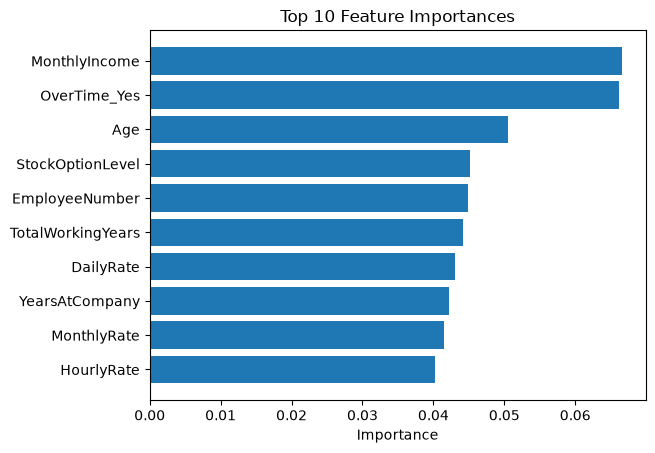

In [18]:
#Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model

top_features = importance_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

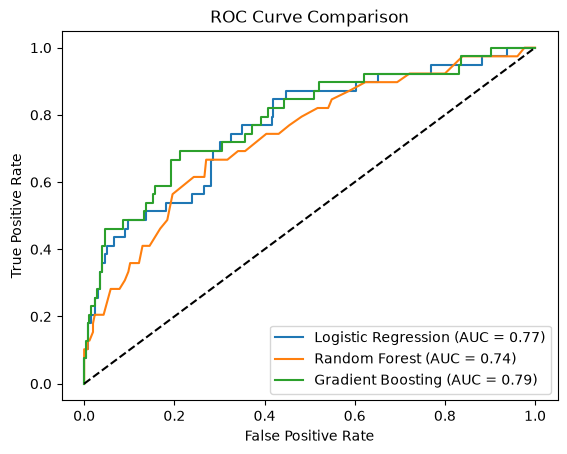

In [19]:
#Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph

from sklearn.metrics import roc_curve, auc

plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#Task 7 — HR Insights & Business Recommendations

The 3 main factors that predict employee leaving are MonthlyIncome, OverTime, and YearsAtCompany. Employees in the Sales department and Sales Representative role should be given more attention because they leave more often. Salary is not the only reason people leave; things like overtime, work-life balance, and job role are also very important. HR should reduce overtime and offer flexible work options, especially for employees who work too much. They should also focus on new employees in their first 1–2 years and give them better support and growth opportunities. One limitation of this model is that it only uses past data, so it cannot predict personal reasons or sudden changes in employees’ decisions.